<a href="https://colab.research.google.com/github/Pedrogui29/TP547--Principios-de-Simulacao-de-Sistemas-de-Comunicacao/blob/main/TrabalhoFinal-Parte1/trabalhofinalparte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto – TP547 Princípios de Simulação de Sistemas de Comunicação

**Alunos**: Henrique Pereira Chagas Corrêa, Pedro Guilherme Fernandes Oliveira

**Artigo:** *S. B. Mafra et al., "Performance Analysis of Full-Duplex Cooperative Communication in Vehicular Ad-Hoc Networks", IFAC-PapersOnLine, 2016.*




## Tema

O artigo estuda o uso de comunicação cooperativa em redes veiculares ad hoc, conhecidas como VANETs. Nesse tipo de rede, veículos podem se comunicar diretamente entre si ou com auxílio de outros nós, chamados relays. O objetivo é melhorar a confiabilidade da comunicação, principalmente em cenários nos quais o canal direto entre transmissor e receptor está prejudicado por obstáculos, mobilidade ou desvanecimento.

O foco principal do artigo é avaliar o uso de relays full-duplex. Diferentemente de relays half-duplex, que transmitem e recebem em tempos ou frequências diferentes, relays full-duplex conseguem transmitir e receber simultaneamente na mesma faixa de frequência. Essa abordagem melhora o aproveitamento do canal, mas introduz o problema da auto-interferência.

## Metodologia

A metodologia do artigo consiste em modelar uma rede veicular composta por uma fonte, um destino e relays cooperativos. Os canais de comunicação são modelados pela distribuição Nakagami-m, que permite representar diferentes condições de propagação, incluindo cenários sub-Rayleigh, Rayleigh e com alguma linha de visada.

A principal métrica analisada é a probabilidade de outage. Um evento de outage ocorre quando a informação mútua do enlace é menor do que a taxa de transmissão desejada. Assim, quanto menor a probabilidade de outage, melhor é o desempenho do sistema.

Neste trabalho, foi reproduzida por simulação de Monte Carlo a Figura 3 do artigo, que compara os esquemas Direct, VDH, VHD e VJD em função da potência de transmissão.

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install scipy

### Importações

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nakagami

### Parâmetros do Sistema

In [ ]:
N = 100000       # número de amostras Monte Carlo
N0 = 1           # densidade espectral de potência do ruído
R = 3            # taxa de transmissão (bpcu)
alpha = 4        # expoente de perda de percurso (path loss)

# Distâncias
d_sd = 1.0       # distância fonte-destino
d_sr = 0.5       # distância fonte-relé
d_rd = 0.5       # distância relé-destino

# Potência média dos canais (path loss)
Omega_sd = d_sd**(-alpha)
Omega_sr = d_sr**(-alpha)
Omega_rd = d_rd**(-alpha)
Omega_rr = 1e-4

# Parâmetros Nakagami-m – Caso 1
m_sd = 0.5
m_sr = 1.0
m_rr = 1.0
m_rd = 1.0

# Faixa de potência de transmissão
Pdb = np.arange(-5, 21, 1)
Plin = 10**(Pdb / 10)

In [ ]:
OP_direct = []
OP_VJD = []
OP_VDH = []
OP_VHD = []

for plin in Plin:
    # Geração dos ganhos de canal |h_ij|^2 com distribuição Nakagami-m
    g_sd = (np.sqrt(Omega_sd) * nakagami.rvs(m_sd, size=N))**2
    g_sr = (np.sqrt(Omega_sr) * nakagami.rvs(m_sr, size=N))**2
    g_rd = (np.sqrt(Omega_rd) * nakagami.rvs(m_rd, size=N))**2
    g_rr = (np.sqrt(Omega_rr) * nakagami.rvs(m_rr, size=N))**2

    # Enlace Direto
    I_direct = np.log2(1 + g_sd * plin / N0)
    OP_direct.append(np.sum(I_direct < R) / N)

    #VJD: relé full-duplex, decodificação conjunta no destino
    I_sr_VJD = np.log2(1 + g_sr * plin / (g_rr * plin + N0))
    I_sd_VJD = np.log2(1 + g_sd * plin / N0)
    I_rd_VJD = np.log2(1 + (g_sd * plin + g_rd * plin) / N0)
    relay_ok_VJD = I_sr_VJD >= R
    O_VJD = np.mean((relay_ok_VJD & (I_rd_VJD < R)) | (~relay_ok_VJD & (I_sd_VJD < R)))
    OP_VJD.append(O_VJD)

    # VDH: relé full-duplex, enlace direto como interferência no destino
    I_sr_VDH = np.log2(1 + g_sr * plin / (g_rr * plin + N0))
    I_rd_VDH = np.log2(1 + g_rd * plin / (g_sd * plin + N0))
    O_VDH = np.mean((I_sr_VDH < R) | (I_rd_VDH < R))
    OP_VDH.append(O_VDH)

    # VHD: relé half-duplex, protocolo IDF, decodificação conjunta
    I_sr_VHD = 0.5 * np.log2(1 + g_sr * plin / N0)
    I_sd_VHD = 0.5 * np.log2(1 + g_sd * plin / N0)

    I_rd_VHD = 0.5 * np.log2(1 + (g_sd * plin + g_rd * plin) / N0)

    relay_ok_VHD = I_sr_VHD >= R
    O_VHD = np.mean((relay_ok_VHD & (I_rd_VHD < R)) | (~relay_ok_VHD & (I_sd_VHD < R)))
    OP_VHD.append(O_VHD)

### Figura 3 – Probabilidade de Outage × Potência de Transmissão P

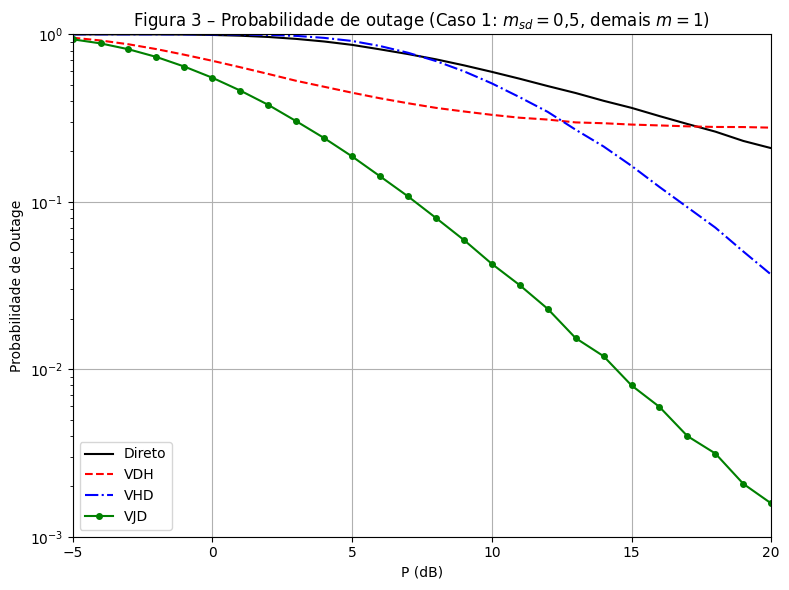

In [ ]:
plt.figure(figsize=(8, 6))
plt.semilogy(Pdb, OP_direct, 'k-',  label='Direto')
plt.semilogy(Pdb, OP_VDH,   'r--', label='VDH')
plt.semilogy(Pdb, OP_VHD,   'b-.', label='VHD')
plt.semilogy(Pdb, OP_VJD,   'g-o', markersize=4, label='VJD')
plt.grid(True)
plt.axis([-5, 20, 1e-3, 1])
plt.xlabel('P (dB)')
plt.ylabel('Probabilidade de Outage')
plt.title('Figura 3 – Probabilidade de outage (Caso 1: $m_{sd}=0{,}5$, demais $m=1$)')
plt.legend()
plt.tight_layout()
plt.show()